In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "boto3", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"])


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


0

## Dependencies

# Notebook 4 — PCA Dimensionality Reduction

**Technique:** Principal Component Analysis (PCA) on 12-dimensional per-vehicle feature vectors

**Goal:** Reduce the 12-dimensional vehicle behaviour space to 2D for visualisation and pattern discovery.

In [2]:
import boto3, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from botocore.client import Config

s3 = boto3.client(
    's3',
    endpoint_url='http://localhost:9000',
    aws_access_key_id='minioadmin',
    aws_secret_access_key='minioadmin',
    config=Config(signature_version='s3v4'),
    region_name='us-east-1'
)
BUCKET = 'bus-history'

FEATURE_COLS = [
    'eventCount', 'avgSpeed', 'maxSpeed', 'stdSpeed', 'idleFraction',
    'totalDistanceKm', 'avgSamplingIntervalS', 'samplingIrregularity',
    'hourSin', 'hourCos', 'headingChanges', 'ignitionOnFraction'
]

In [3]:
def load_feature_vectors(max_objects=5000):
    records = []
    paginator = s3.get_paginator('list_objects_v2')
    count = 0
    for page in paginator.paginate(Bucket=BUCKET, Prefix='features/vehicle-hourly/'):
        for obj in page.get('Contents', []):
            if count >= max_objects: break
            body = s3.get_object(Bucket=BUCKET, Key=obj['Key'])['Body'].read()
            records.append(json.loads(body))
            count += 1
    return pd.DataFrame(records)

df = load_feature_vectors()
print(f'Loaded {len(df):,} feature vectors')
print(df[['routeNo','hourOfDay','avgSpeed','eventCount']].head())

Loaded 1,737 feature vectors
  routeNo  hourOfDay   avgSpeed  eventCount
0      01         10  10.925926        76.0
1      01         11  11.623656       359.0
2      01         12  16.756944       351.0
3      01         13  18.553991       359.0
4      01         10   0.000000        75.0


In [4]:
for col in FEATURE_COLS:
    df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)

X = df[FEATURE_COLS].values
X_scaled = StandardScaler().fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print('Mean after scaling:', X_scaled.mean(axis=0).round(3))
print('Std  after scaling:', X_scaled.std(axis=0).round(3))

Feature matrix shape: (1737, 12)
Mean after scaling: [-0. -0. -0.  0. -0. -0. -0. -0. -0. -0.  0. -0.]
Std  after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
pca = PCA(n_components=min(12, len(df)))
X_pca = pca.fit_transform(X_scaled)

print('Explained variance ratio per component:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.3f} ({100*var:.1f}%)')
print(f'\nPC1+PC2 captures {100*pca.explained_variance_ratio_[:2].sum():.1f}% of total variance')

Explained variance ratio per component:
  PC1: 0.399 (39.9%)
  PC2: 0.173 (17.3%)
  PC3: 0.120 (12.0%)
  PC4: 0.087 (8.7%)
  PC5: 0.065 (6.5%)
  PC6: 0.055 (5.5%)
  PC7: 0.032 (3.2%)
  PC8: 0.027 (2.7%)
  PC9: 0.018 (1.8%)
  PC10: 0.014 (1.4%)
  PC11: 0.007 (0.7%)
  PC12: 0.003 (0.3%)

PC1+PC2 captures 57.2% of total variance


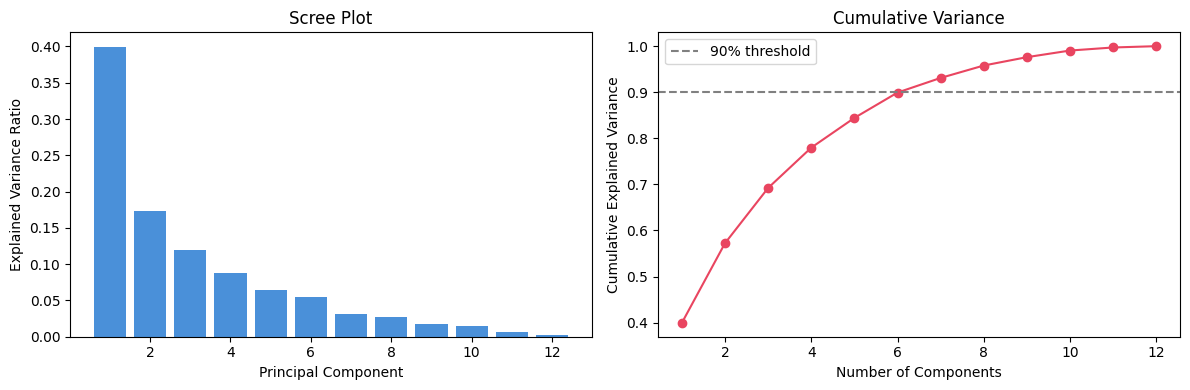

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, color='#4a90d9')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

cum_var = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cum_var)+1), cum_var, marker='o', color='#e94560')
axes[1].axhline(0.9, linestyle='--', color='gray', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance')
axes[1].legend()
plt.tight_layout()
plt.savefig('/tmp/pca_scree.png', dpi=150)
plt.show()

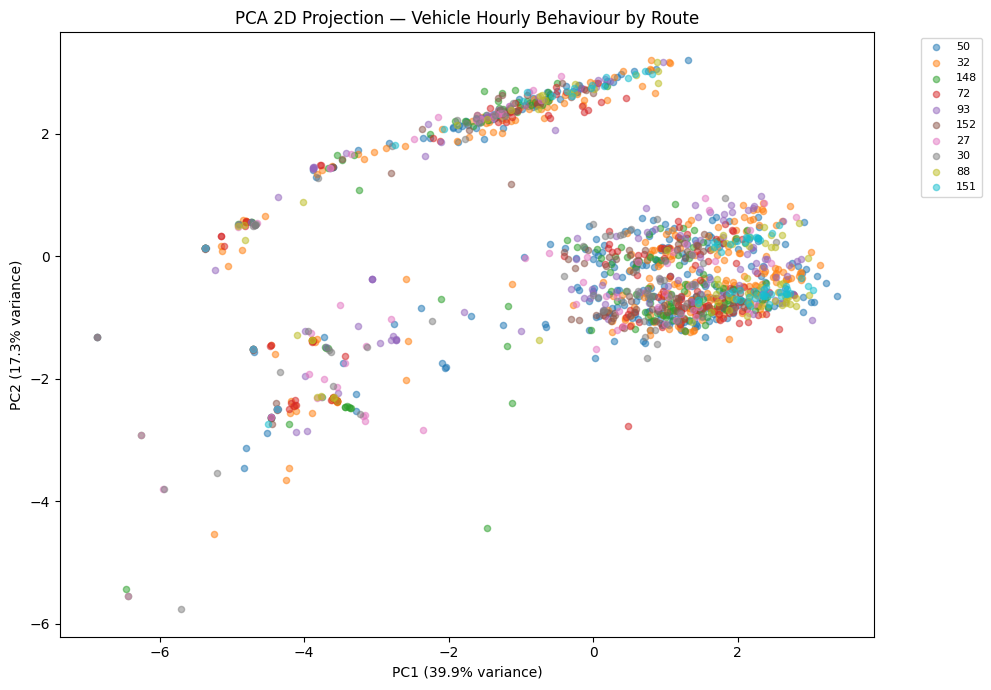

In [7]:
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

top_routes = df['routeNo'].value_counts().head(10).index.tolist()
plot_df = df[df['routeNo'].isin(top_routes)]

fig, ax = plt.subplots(figsize=(10, 7))
for route in top_routes:
    subset = plot_df[plot_df['routeNo'] == route]
    ax.scatter(subset['PC1'], subset['PC2'], label=route, alpha=0.5, s=20)

ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)')
ax.set_title('PCA 2D Projection — Vehicle Hourly Behaviour by Route')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('/tmp/pca_scatter.png', dpi=150)
plt.show()

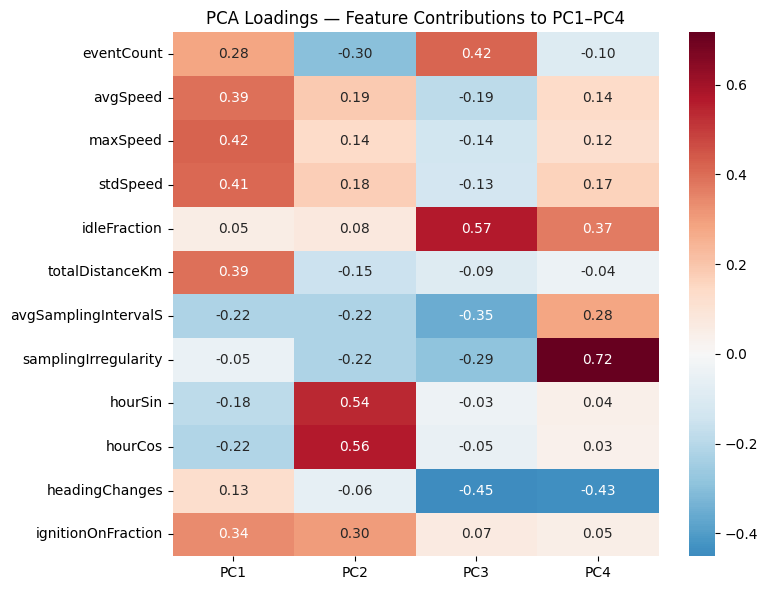

PC1 dominated by speed features = activity axis
PC2 dominated by sampling features = data quality axis


In [8]:
# mỗi feature đóng góp bao nhiêu vào từng PC
loadings = pd.DataFrame(
    pca.components_[:4].T,
    index=FEATURE_COLS,
    columns=[f'PC{i+1}' for i in range(4)]
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('PCA Loadings — Feature Contributions to PC1–PC4')
plt.tight_layout()
plt.savefig('/tmp/pca_loadings.png', dpi=150)
plt.show()
print('PC1 dominated by speed features = activity axis')
print('PC2 dominated by sampling features = data quality axis')